In [36]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor


In [3]:
df = pd.read_csv("cleaned_data.csv")

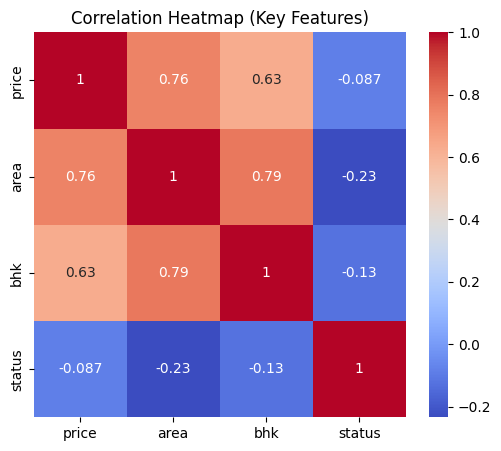

In [24]:
important_cols = ['price', 'area', 'bhk', 'status']
corr = df[important_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Key Features)")
plt.show()


In [38]:
x = df.drop(columns=['price'])
y = df['price']

X_train , X_test , y_train , y_test = train_test_split( x , y , test_size=0.2 , random_state=42 )

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print(mean_absolute_error(y_test , y_pred))
print(r2_score(y_test ,y_pred))

importance = model.feature_importances_

feature_importance = pd.DataFrame({'feature': x.columns,'importance':importance}).sort_values(by = 'importance',ascending=False)
feature_importance.head(10)

40.9752390044868
0.8002714657098969


,feature,importance
1,area,0.674432
0,bhk,0.128081
45,region_other,0.070062
41,region_Thane West,0.020122
26,region_Andheri West,0.016447
47,age_Unknown,0.012432
2,status,0.011944
46,age_Resale,0.011085
40,region_Powai,0.010693
4,type_Villa,0.007515


In [39]:
y_pred = model.predict(X_test)


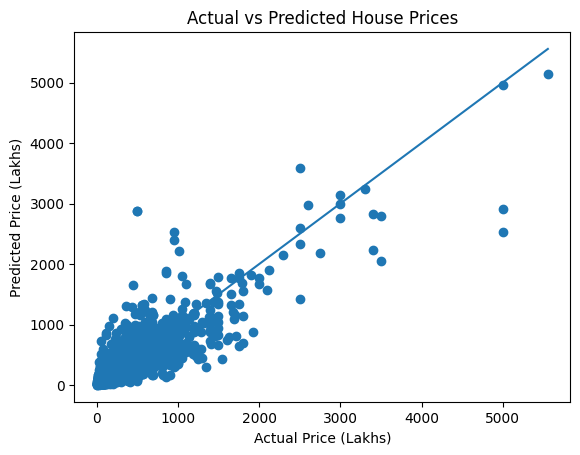

In [40]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price (Lakhs)")
plt.ylabel("Predicted Price (Lakhs)")
plt.title("Actual vs Predicted House Prices")

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.show()

In [6]:
x.columns

Index(['bhk', 'area', 'status', 'type_Studio Apartment', 'type_Villa',
       'type_other', 'locality_Amar Vinay Heritage', 'locality_Cosmos Horizon',
       'locality_Hiranandani Estate', 'locality_Hiranandani Meadows',
       'locality_Hiranandani One Hiranandani Park',
       'locality_JP Codename Dream Home Tower B',
       'locality_JP North Barcelona', 'locality_Lodha Codename Premier',
       'locality_Neelkanth Greens', 'locality_Neelkanth Palms',
       'locality_Raj Akshay', 'locality_Reputed Builder Wild Wood Park 2',
       'locality_Runwal Bliss', 'locality_Runwal Garden City Dahlia',
       'locality_Runwal Gardens', 'locality_Sheth Avalon',
       'locality_T Bhimjyani The Verraton', 'locality_Umiya Oasis',
       'locality_Vasant Vasant Vihar', 'locality_other', 'region_Andheri West',
       'region_Borivali East', 'region_Chembur', 'region_Dombivali',
       'region_Ghatkopar East', 'region_Kalyan West', 'region_Kandivali East',
       'region_Kandivali West', 'region_

In [45]:
new_house = x.iloc[0].copy()
new_house['bhk'] = 5
new_house['area'] = 5000
new_house['status'] = 0

new_house = pd.DataFrame([new_house])

predicted_price = model.predict(new_house)
predicted_price[0]

np.float64(3374.686666666667)

In [19]:
df['price'].describe()

count    76038.000000
mean       168.417795
std        217.665511
min          4.490000
25%         64.000000
50%        110.000000
75%        194.000000
max       6000.000000
Name: price, dtype: float64

In [ ]:
import joblib
joblib.dump(model,"house_price_model.pkl")

['house_price_model.pkl']

In [22]:
joblib.dump(x.columns.tolist(), "model_features.pkl")

['model_features.pkl']